In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.rcParams['font.family'] = 'Arial'


MASTER = 'Pathways Master.xlsx'

In [42]:
def make_df(tab):
    df = pd.read_excel(MASTER, tab, usecols=range(0, 12))[:16] #Read in data from a tab, use just columns w raw data
    df = df.rename(columns={'Unnamed: 0': 'Community Colleges'}) #Name indx column
    df.set_index('Community Colleges', inplace=True) #set indx
    df = df.astype(float) #make all values floats
    return df

In [43]:
total_ch = make_df('Credit Hours') # Total Credit Hours per Degree
pct_as = make_df('% Credit Hours') #    Percent of AS that Transfers
curr_comp = make_df('Curricular Complexity') # Curricular Complexity
cost = make_df('Cost') # Cost

In [44]:
def make_graph(df, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    # make boxplot of just transfer degrees
    sns.boxplot(data=df.loc['Berkshire':], linewidth=1.5, zorder=1)
    
    # overlay (z=2) scatterplot with just res degrees 
    if ylabel != 'Percent of AS':
        plt.scatter(df.columns, df.loc['Resident'], color='teal', label='Resident Degrees', zorder=2)
    
    #Customization!! :D
    if filename=='cost':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend()
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(fontsize=10, rotation=90)
    plt.yticks(fontsize=10)
    plt.savefig(f'images/{filename}.png', bbox_inches = 'tight')
    plt.show()

In [45]:
#make_graph(total_ch, 'Total Credit Hours of Transfer Degrees', 'Credit Hours', 'total_ch')

In [46]:
#make_graph(pct_as, 'Percent of ASCS that Transfers to each Four-Year', 'Percent of AS', 'pct_as')

In [47]:
#make_graph(curr_comp, 'Curricular Complexity of Transfer vs Resident Degrees', 'Curricular Complexity', 'curr_comp')

In [48]:
#make_graph(cost, 'Cost of Tuition & Fees over 120 Credits', 'Dollars', 'cost')

In [49]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=cat_df['pct_as'], y=cat_df['total_ch'], hue=cat_df['Category'])
# # plt.scatter(pct_as, total_ch)
# plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.legend()
# plt.title('Percent AS / Total Credit Hours for Degree')
# plt.ylabel('Credit Hours')
# plt.xlabel('% Of AS that Transfers')
# plt.xticks(fontsize=10, rotation=90)
# plt.yticks(fontsize=10)
# plt.savefig('images/pct-total.png', bbox_inches = 'tight')
# #plt.show()

In [50]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=cat_df['pct_as'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# # plt.scatter(pct_as, total_ch)
# plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.legend()
# plt.title('Percent AS / Curricular Complexity')
# plt.ylabel('Curricular Complexity')
# plt.xlabel('% Of AS that Transfers')
# plt.xticks(fontsize=10, rotation=90)
# plt.yticks(fontsize=10)
# plt.savefig('images/pct-curr_comp.png', bbox_inches = 'tight')
# #plt.show()

In [51]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=cat_df['total_ch'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# # plt.scatter(pct_as, total_ch)
# plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.legend()
# plt.title('Total Credit Hours for Degree / Curricular Complexity')
# plt.ylabel('Curricular Complexity')
# plt.xlabel('Credit Hours')
# plt.xticks(fontsize=10, rotation=90)
# plt.yticks(fontsize=10)
# plt.savefig('images/total-curr_comp.png', bbox_inches = 'tight')
# #plt.show()

In [52]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=cat_df['total_ch'], y=cat_df['cost'], hue=cat_df['Category'])
# # plt.scatter(pct_as, total_ch)
# plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.legend()
# plt.title('Total Credit Hours for Degree / Degree Cost')
# plt.ylabel('Cost ($)')
# plt.xlabel('Credit Hours')
# plt.xticks(fontsize=10, rotation=90)
# plt.yticks(fontsize=10)
# plt.savefig('images/total-cost.png', bbox_inches = 'tight')
# #plt.show()

In [53]:
# Matrix of analyzed CC → 4-year pairs
# analyzed = total_ch.loc['Berkshire':].notna()

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.imshow(analyzed.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)

# ax.set_xticks(range(len(analyzed.columns)))
# ax.set_xticklabels(analyzed.columns, rotation=45, ha='right', fontsize=10)
# ax.set_yticks(range(len(analyzed.index)))
# ax.set_yticklabels(analyzed.index, fontsize=10)

# for i in range(len(analyzed.index)):
#     for j in range(len(analyzed.columns)):
#         ax.text(j, i, '✓' if analyzed.values[i, j] else '', ha='center', va='center',
#                 fontsize=12, color='white', fontweight='bold')

# ax.set_title('Community Colleges and 4-Years within 50 Miles of Eachother', fontsize=13)
# plt.tight_layout()
# plt.savefig('images/analyzed_pairs.png', bbox_inches='tight')
# plt.show()

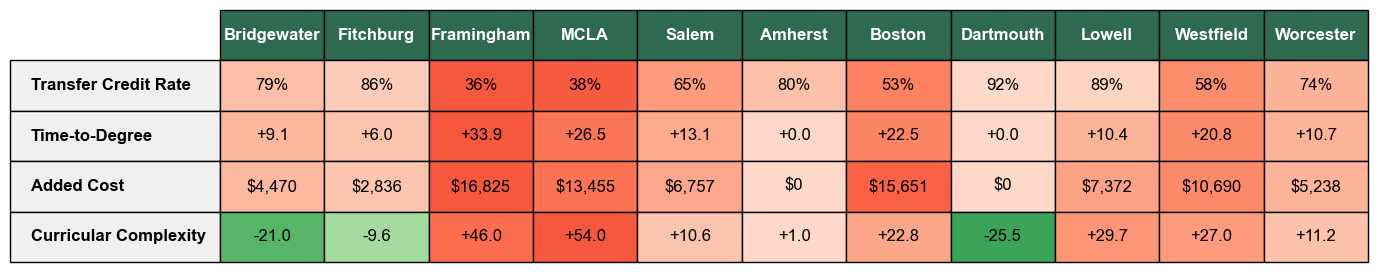

In [54]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import Reds, Greens

cc = slice('Berkshire', None)

avg_pct  = pct_as.loc[cc].mean()
avg_ch   = (total_ch.loc[cc] - total_ch.loc['Resident']).mean()
avg_cc   = (curr_comp.loc[cc] - curr_comp.loc['Resident']).mean()
avg_cost = (cost.loc[cc] - cost.loc['Resident']).mean()

metrics = {
    'Transfer Credit Rate':          (avg_pct,  True,  '{:.0%}'),
    'Time-to-Degree':     (avg_ch,   False, '{:+.1f}'),
    'Added Cost':             (avg_cost, False, '${:,.0f}'),
    'Curricular Complexity': (avg_cc,   False, '{:+.1f}'),
}

unis = avg_pct.index.tolist()
col_labels = [u.replace('UMass ', '') for u in unis]
cell_text, cell_colors = [], []

for label, (series, higher_is_better, fmt) in metrics.items():
    row_vals = series.reindex(unis)
    cell_text.append([fmt.format(v) if not np.isnan(v) else '—' for v in row_vals])

    pos_vals = row_vals[row_vals >= 0]
    neg_vals = row_vals[row_vals < 0]
    pos_norm = Normalize(vmin=pos_vals.min() if len(pos_vals) else 0, vmax=pos_vals.max() if len(pos_vals) else 1)
    neg_norm = Normalize(vmin=neg_vals.min() if len(neg_vals) else -1, vmax=0)

    colors = []
    for v in row_vals:
        if np.isnan(v):
            colors.append('#f5f5f5')
        elif v < 0:
            colors.append(Greens(0.2 + (1 - neg_norm(v)) * 0.45))
        else:
            scalar = (1 - pos_norm(v)) if higher_is_better else pos_norm(v)
            colors.append(Reds(0.15 + scalar * 0.4))
    cell_colors.append(colors)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=list(metrics.keys()),
    colLabels=col_labels,
    cellLoc='center',
    bbox=[0, 0, 1, 1],
    cellColours=cell_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(12)

for j in range(len(unis)):
    cell = table[(0, j)]
    cell.set_facecolor('#2d6a4f')
    cell.set_text_props(color='white', fontweight='bold')

for i in range(len(metrics)):
    table[(i + 1, -1)].set_facecolor('#f0f0f0')
    table[(i + 1, -1)].set_text_props(fontweight='bold')

fig.subplots_adjust(top=0.9, bottom=0, left=0.18, right=1.0)
plt.savefig('images/scorecard.png', bbox_inches='tight', dpi=150)
plt.show()


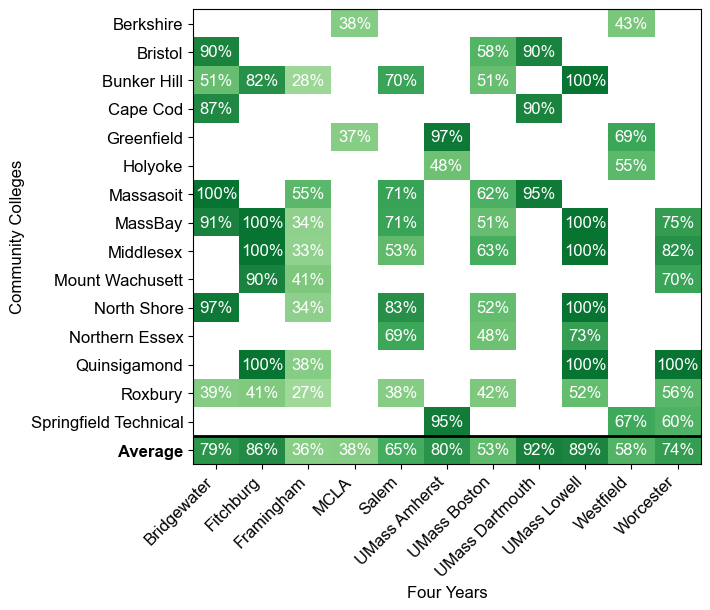

In [55]:
data = pct_as.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')
data.loc['Average'] = data.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(data.values, cmap='Greens', aspect='auto', vmin=-.33, vmax=1.25)

ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=12)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index, fontsize=12)

for label in ax.get_yticklabels():
    if label.get_text() == 'Average':
        label.set_fontweight('bold')

# Separator bar above the Average row
ax.axhline(y=len(data.index) - 1.5, color='black', linewidth=2)

for i in range(len(data.index)):
    for j in range(len(data.columns)):
        v = data.values[i, j]
        if not np.isnan(v):
            #color = 'darkslategray' if v < 0.5 else 'white'
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=12, color='white')
plt.tight_layout()
plt.xlabel("Four Years", fontsize=12)
plt.ylabel("Community Colleges", fontsize=12)
plt.savefig('images/pct_matrix.png', bbox_inches='tight')
plt.show()

In [56]:
data.drop('Average', inplace=True)
data.stack().mean()


0.6775892631344262

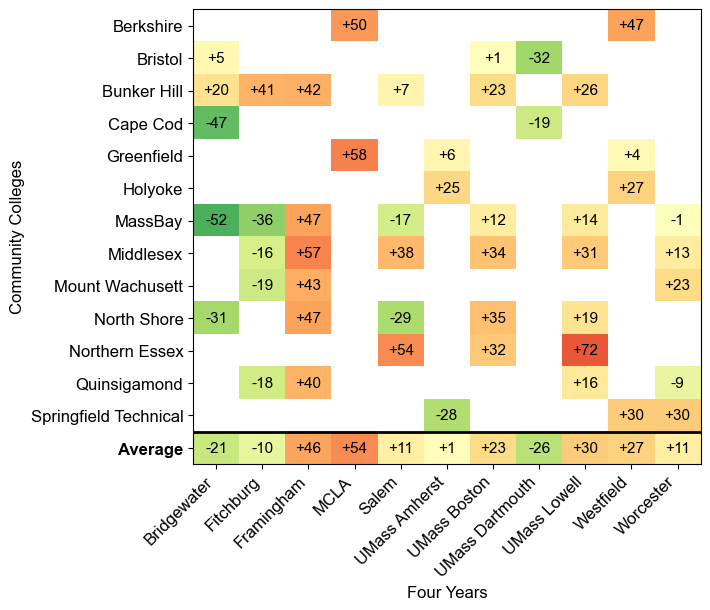

In [57]:
extra_cc = curr_comp.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')
extra_cc = extra_cc.subtract(curr_comp.loc['Resident'])
extra_cc.loc['Average'] = extra_cc.mean()
extra_cc.drop('Roxbury', inplace=True)
extra_cc.drop('Massasoit', inplace=True)


from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=extra_cc.min().min()*1.5, vcenter=0, vmax=extra_cc.max().max()*1.5)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(extra_cc.values, cmap='RdYlGn_r', aspect='auto', norm=norm)

ax.set_xticks(range(len(extra_cc.columns)))
ax.set_xticklabels(extra_cc.columns, rotation=45, ha='right', fontsize=12)
ax.set_yticks(range(len(extra_cc.index)))
ax.set_yticklabels(extra_cc.index, fontsize=12)

for label in ax.get_yticklabels():
    if label.get_text() == 'Average':
        label.set_fontweight('bold')

ax.axhline(y=len(extra_cc.index) - 1.5, color='black', linewidth=2)
        
for i in range(len(extra_cc.index)):
    for j in range(len(extra_cc.columns)):
        v = extra_cc.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.0f}', ha='center', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.xlabel("Four Years", fontsize=12)
plt.ylabel("Community Colleges", fontsize=12)
plt.savefig('images/curr_comp_matrix.png', bbox_inches='tight')
plt.show()

In [58]:
extra_cc.drop('Average', inplace=True)
extra_cc.stack().mean()


14.591836734693878

12.918367346938776


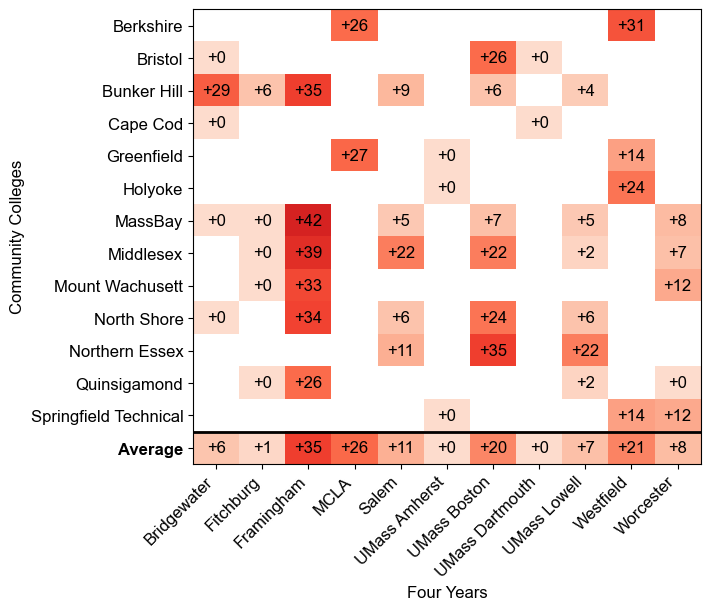

In [59]:
extra_ch = total_ch.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore') - 120

extra_ch.drop('Roxbury', inplace=True)
extra_ch.drop('Massasoit', inplace=True)
print(extra_ch.stack().mean())
extra_ch.loc['Average'] = extra_ch.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(extra_ch.values, cmap='Reds', aspect='auto', vmin=-10, vmax=extra_ch.max().max() * 1.5)

ax.set_xticks(range(len(extra_ch.columns)))
ax.set_xticklabels(extra_ch.columns, rotation=45, ha='right', fontsize=12)
ax.set_yticks(range(len(extra_ch.index)))
ax.set_yticklabels(extra_ch.index, fontsize=12)

for label in ax.get_yticklabels():
    if label.get_text() == 'Average':
        label.set_fontweight('bold')

ax.axhline(y=len(extra_ch.index) - 1.5, color='black', linewidth=2)

for i in range(len(extra_ch.index)):
    for j in range(len(extra_ch.columns)):
        v = extra_ch.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'+{v:.0f}', ha='center', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.xlabel("Four Years", fontsize=12)
plt.ylabel("Community Colleges", fontsize=12)
plt.savefig('images/extra_ch_matrix.png', bbox_inches='tight')
plt.show()

7129.410884387756


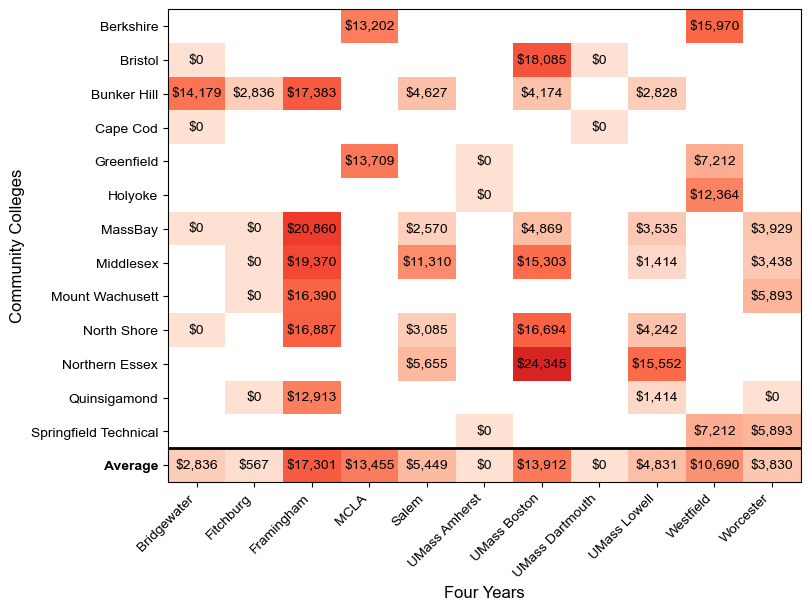

In [60]:
extra_cost = cost.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')

extra_cost.drop('Roxbury', inplace=True)
extra_cost.drop('Massasoit', inplace=True)
print(extra_cost.stack().mean())
extra_cost.loc['Average'] = extra_cost.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(extra_cost.values, cmap='Reds', aspect='auto', vmin=-5000, vmax=extra_cost.max().max() * 1.5)

ax.set_xticks(range(len(extra_cost.columns)))
ax.set_xticklabels(extra_cost.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(extra_cost.index)))
ax.set_yticklabels(extra_cost.index, fontsize=10)

for label in ax.get_yticklabels():
    if label.get_text() == 'Average':
        label.set_fontweight('bold')

ax.axhline(y=len(extra_cost.index) - 1.5, color='black', linewidth=2)

for i in range(len(extra_cost.index)):
    for j in range(len(extra_cost.columns)):
        v = extra_cost.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'${v:,.0f}', ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.xlabel("Four Years", fontsize=12)
plt.ylabel("Community Colleges", fontsize=12)
plt.savefig('images/cost_matrix.png', bbox_inches='tight')
plt.show()